In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as p

df = pd.read_csv("mission_launches.csv")
df.head(5)


,Unnamed: 0.1,Unnamed: 0,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
0,0,0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success
1,1,1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success
2,2,2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success
3,3,3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.0,Success
4,4,4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.0,Success


In [42]:
df.shape

(943, 8)

In [ ]:
df = df.drop(columns=['Unnamed: 0.1', 'Unnamed: 0'], errors='ignore')


Dropped the Unnamed columns because they added no useful information to the dataset.

In [27]:
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

df = df.dropna(subset=['Price'])



Converted the Price column to numeric values and removed rows with missing or invalid prices.

In [41]:
df['Year'] = pd.to_datetime(df['Date'], errors='coerce').dt.year
df = df.dropna(subset=['Date', 'Year'])


Extracted the year from Date and removed rows with missing Date or Year values.

In [35]:
df.isna().sum()

Organisation      0
Location          0
Date              0
Detail            0
Rocket_Status     0
Price             0
Mission_Status    0
dtype: int64

In [46]:
df.drop_duplicates(inplace=True)

df.duplicated().sum()


np.int64(0)

Removed duplicate rows and confirmed no duplicates remain.

In [51]:
df.dtypes

Organisation       object
Location           object
Date               object
Detail             object
Rocket_Status      object
Price             float64
Mission_Status     object
Year                int64
dtype: object

In [38]:
df['Price'] = pd.to_numeric(df['Price'], errors='coerce').astype(float)
print(df['Price'].dtypes)
print(df[['Price']].head())



float64
    Price
0   50.00
1   29.75
3   65.00
4  145.00
5   64.68


Converted the Price column to float and displayed its type and first few values.

In [39]:
df['Price'] = df['Price'].replace('', pd.NA)
df = df.dropna(subset=['Price'])
df.head(5)




,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.00,Success
1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success
3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.00,Success
4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.00,Success
5,CASC,"LC-9, Taiyuan Satellite Launch Center, China","Sat Jul 25, 2020 03:13 UTC","Long March 4B | Ziyuan-3 03, Apocalypse-10 & N...",StatusActive,64.68,Success


Replaced empty Price values with NA and removed rows missing Price.


In [40]:
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')


highest_org = df.groupby('Organisation')['Price'].sum().reset_index()

highest_org = highest_org.sort_values(by='Price', ascending=False)
highest_org.head()





,Organisation,Price
14,NASA,61200.00
0,Arianespace,16345.00
20,ULA,14798.00
2,CASC,6340.26
19,SpaceX,5444.00


Calculated total Price per Organisation and displayed the top organisations by spending.


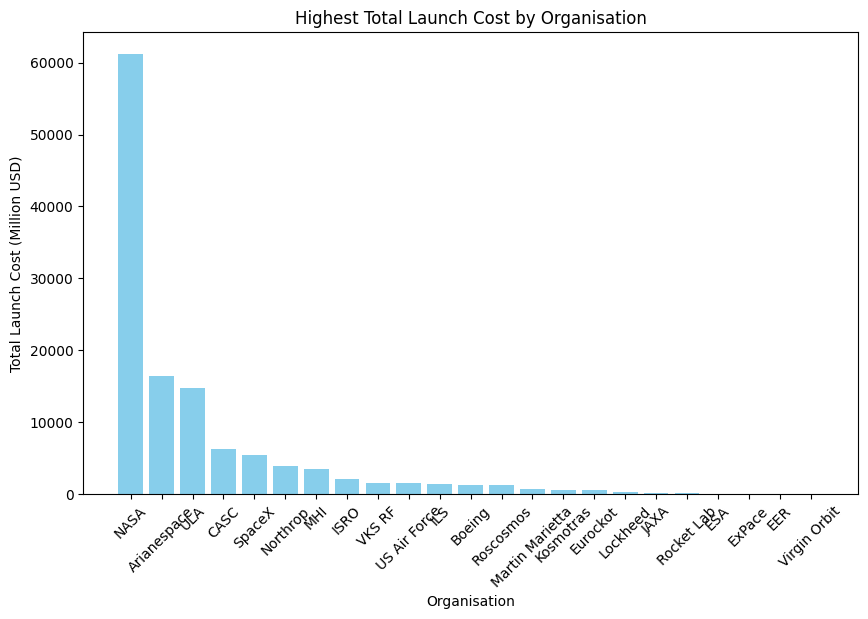

In [93]:
highest_org = highest_org.reset_index()

plt.figure(figsize=(10,6))
plt.bar(highest_org['Organisation'], highest_org['Price'], color='skyblue')
plt.xlabel('Organisation')
plt.ylabel('Total Launch Cost (Million USD)')
plt.title('Highest Total Launch Cost by Organisation')
plt.xticks(rotation=45)
plt.show()




Plotted a bar chart showing total launch costs per organisation, highlighting the highest spenders.


In [54]:
Most_Mission = df.groupby('Organisation')['Mission_Status'].count().reset_index()
Most_Mission =Most_Mission.sort_values(by='Mission_Status', ascending=False)
Most_Mission.head(10)


,Organisation,Mission_Status
2,CASC,157
14,NASA,136
18,SpaceX,99
19,ULA,98
0,Arianespace,96
15,Northrop,83
8,ISRO,66
12,MHI,37
21,VKS RF,33
20,US Air Force,25


Counted missions per organisation and displayed the top 10 with the most launches.


In [94]:
total_missions = df.groupby('Organisation').size()

successful_missions = df[df['Mission_Status'] == 'Success'].groupby('Organisation').size()

success_rate = (successful_missions / total_missions * 100).reset_index()

success_rate.columns = ['Organisation', 'Success_Rate']

success_rate = success_rate.sort_values(by='Success_Rate', ascending=False)

print(success_rate.head(20))


       Organisation  Success_Rate
12              MHI    100.000000
9              JAXA    100.000000
4               ESA    100.000000
7               ILS    100.000000
11         Lockheed    100.000000
19              ULA     98.979592
14             NASA     98.529412
0       Arianespace     96.875000
2              CASC     96.153846
17        Roscosmos     95.652174
10        Kosmotras     95.000000
18           SpaceX     93.939394
5          Eurockot     92.307692
20     US Air Force     92.000000
21           VKS RF     90.909091
15         Northrop     89.156627
8              ISRO     87.878788
1            Boeing     85.714286
16       Rocket Lab     84.615385
13  Martin Marietta     77.777778


Calculated mission success rates per organisation and listed the top 20 highest rates.


In [ ]:
import plotly.express as px

fig = px.pie(
    success_rate,
    names='Organisation',
    values='Success_Rate',
    title='Rocket Launch Success Rate by Organisation',
    hover_data=['Success_Rate'],
    width=600,  
    height=600 

)

fig.update_traces(textinfo='percent+label')  
fig.show()


Created a pie chart showing rocket launch success rates for each organisation.


In [66]:
missions_by_year_org = df.groupby(['Year', 'Organisation']).size().reset_index(name='Missions')
missions_by_year_org.sort_values('Missions', ascending=False).head(10)
                                                        



,Year,Organisation,Missions
220,2018,CASC,27
228,2018,SpaceX,21
232,2019,CASC,21
216,2017,SpaceX,18
244,2020,CASC,16
197,2016,CASC,15
251,2020,SpaceX,13
240,2019,SpaceX,13
187,2014,ULA,13
208,2017,CASC,12


CASC launched the most mission in any given year

In [67]:
cost_over_time = df.groupby('Year')['Price'].median().reset_index()
cost_over_time.head(5)



,Year,Price
0,1964,63.23
1,1965,63.23
2,1966,59.00
3,1967,59.00
4,1968,59.00


Calculated the median launch cost per year and displayed the first 5 records.


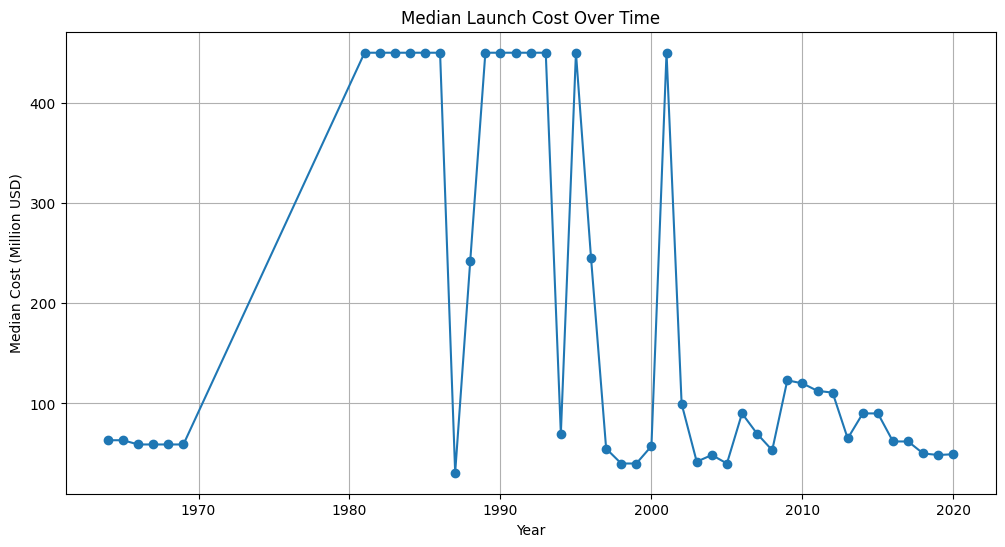

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(cost_over_time['Year'], cost_over_time['Price'], marker='o')
plt.title('Median Launch Cost Over Time')
plt.xlabel('Year')
plt.ylabel('Median Cost (Million USD)')
plt.grid(True)
plt.show()


Plotted median launch costs over time to visualize trends year by year.


In [56]:
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.month_name()

launches_by_month = df['Month_Name'].value_counts()
print(launches_by_month)





Month_Name
December     89
September    87
June         85
April        85
May          83
October      83
August       82
March        76
July         75
November     72
January      65
February     60
Name: count, dtype: int64


Extracted month info from Date and counted the number of launches per month.


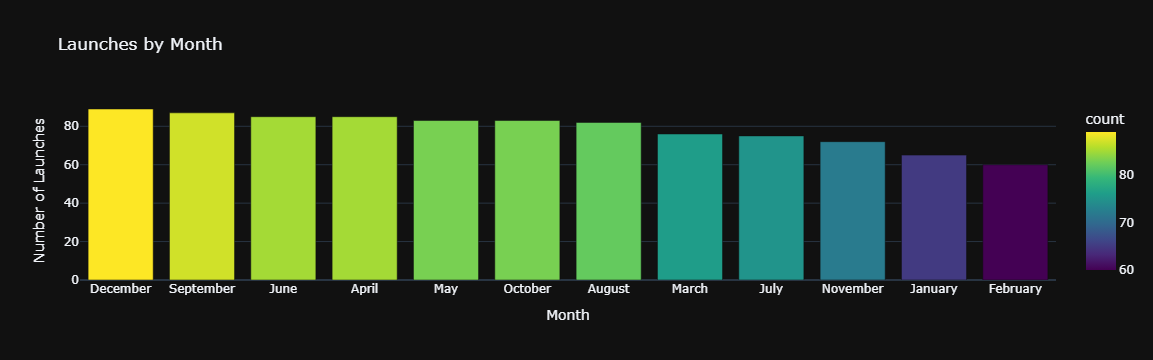

In [84]:
fig = px.bar(
    launches_by_month.reset_index(),
    x='Month_Name',
    y='count',
    title='Launches by Month',
    color='count',
    color_continuous_scale='Viridis'  
)

fig.update_layout(
    xaxis_title='Month',
    yaxis_title='Number of Launches',
    template='plotly_dark'
)

fig.show()


Created a colored bar chart showing the number of launches for each month.


In [77]:
active_rockets = df['Rocket_Status'].value_counts()
print(active_rockets)


Rocket_Status
StatusActive     583
StatusRetired    360
Name: count, dtype: int64


Counted and displayed the number of launches by rocket status.
